<a href="https://colab.research.google.com/github/luismlopes/Complete-Python-3-Bootcamp/blob/master/Learner's_Notebook_Project_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<center><p float="center">
  <img src="https://mma.prnewswire.com/media/1458111/Great_Learning_Logo.jpg?p=facebook" width="200" height="100"/>
</p></center>

<h1><center><font size=10> Generative AI for NLP Program</center></font></h1>
<h1><center> Project-1 </center></h1>

# **GA-NLP Project-1 : Financial Product Complaint Classification and Summarization**

## **Business Context**

### **Description**
*In the modern financial industry, customer complaints play a crucial role in identifying areas where financial institutions can improve their services. Effectively categorizing these complaints into specific product categories, such as credit reports, student loans, or money transfers, is essential for addressing customer concerns promptly by routing the tickets to relevant personnel. Leveraging Generative AI for text classification can help financial institutions better understand customer grievances and respond more efficiently. Apart from this, a summary of the customer complaint helps the support personnel quickly grasp the gist of the grievance*

### **Objective**
*The primary goal of this project is to utilize Generative AI techniques to improve the classification and summarization of customer complaints in the financial sector.
Specifically, the project will focus on:*

1. **Text-to-Label Classification:** *Implementing Zero-shot and Few-shot prompting methods to accurately classify customer complaints into relevant product categories.*
2. **Text-to-Text Summarization:** *Using Zero-shot prompting to generate concise summaries of customer complaints, enabling more personalized and effective responses.*

### **Conclusion**
*Upon completing this project, you will have the capability to develop solutions for LLM-based text classification and summarization. These tools will enable financial institutions to automate the complaint handling process, leading to faster, more accurate responses to customer issues, improved customer satisfaction, and enhanced compliance with industry regulations. This project will also provide you with valuable skills and experience that can be applied to a range of real-world business challenges.*


# **Section 1 : Setting Up for Prompt Engineering with Mistral Model**

### **Install & Importing neccessary libraries**

In [1]:
!apt-get update
!apt-get install -y ninja-build cmake
!pip install ipywidgets --upgrade

Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:2 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:3 https://cli.github.com/packages stable InRelease [3,917 B]
Get:4 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [85.2 kB]
Get:5 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [2,385 kB]
Get:6 https://cli.github.com/packages stable/main amd64 Packages [357 B]
Hit:7 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:8 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:10 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Hit:11 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:12 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:13 https://r2u.stat.illinois.edu/ubuntu 

In [3]:
import torch

In [5]:
# This part of code will skip all the un-necessary warnings which can occur during the execution of this project.
import warnings
warnings.filterwarnings("ignore", category=Warning)

In [6]:
# Installation for GPU llama-cpp-python==0.2.69
!CMAKE_ARGS="-DLLAMA_CUDA=on" pip install llama-cpp-python==0.2.69
# For downloading the models from HF Hub
!pip install huggingface_hub

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.5/42.5 MB 42.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 5.2 MB/s eta 0:00:00
  Created wheel for llama-cpp-python: filename=llama_cpp_python-0.2.69-cp312-cp312-linux_x86_64.whl size=55915706 sha256=7ab6d390a4216b149792d5baf39c65c7006f3c393e2d73c20d8a3e0becad691c
  Stored in directory: /root/.cache/pip/wheels/34/c4/0f/5e9491cacdb3fbcf00fe83a619f2579f1e9fcd2a556694a56f
Successfully built llama-cpp-python


In [9]:
!pip install evaluate
!pip install bert-score

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 5.9 MB/s eta 0:00:00


> ***If prompted, restart the session. After restarting, you can continue executing the notebook from where you left off without needing to start from the beginning. Starting over might cause you to get stuck in a loop.***


In [7]:
!pip freeze > requirement.txt

In [10]:
# Basic Imports for Libraries
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score

import pandas as pd
import numpy as np
from tqdm import tqdm
import json
import re

import torch
import evaluate

# from google.colab import drive
import locale

### **Question 1: Importing Libaries and Mistral Model (3 Marks)**

- For the Mistral Model name or path and model basename, refer to the **Week 3 Additional Content: Prompt Engineering Fundamentals**
- Code Notebook: Self-Consistency and Tree-of-Thought Prompting with Llama 2 and Mistral.





https://huggingface.co/TheBloke/Mistral-7B-Instruct-v0.2-GGUF/blob/main/mistral-7b-instruct-v0.2.Q5_K_M.gguf

In [11]:
from huggingface_hub import hf_hub_download
from llama_cpp import Llama

If the model loading process is taking longer than expected, try restarting the kernel and rerunning the notebook.

In [12]:
model_name_or_path = "TheBloke/Mistral-7B-Instruct-v0.2-GGUF"
model_basename = "mistral-7b-instruct-v0.2.Q5_K_M.gguf"

In [13]:
model_path = hf_hub_download(
    repo_id= model_name_or_path,
    filename= model_basename
    )

mistral-7b-instruct-v0.2.Q5_K_M.gguf:   0%|          | 0.00/5.13G [00:00<?, ?B/s]

In [16]:
lcpp_llm = Llama(
        model_path=model_path,
        n_threads= 2,  # CPU cores
        n_batch= 512,  # Should be between 1 and n_ctx, consider the amount of VRAM in your GPU.
        n_gpu_layers= 32,  # Change this value based on your model and your GPU VRAM pool.
        n_ctx= 4096,  # Context window
    )

llama_model_loader: loaded meta data with 24 key-value pairs and 291 tensors from /root/.cache/huggingface/hub/models--TheBloke--Mistral-7B-Instruct-v0.2-GGUF/snapshots/3a6fbf4a41a1d52e415a4958cde6856d34b2db93/mistral-7b-instruct-v0.2.Q5_K_M.gguf (version GGUF V3 (latest))
llama_model_loader: Dumping metadata keys/values. Note: KV overrides do not apply in this output.
llama_model_loader: - kv   0:                       general.architecture str              = llama
llama_model_loader: - kv   1:                               general.name str              = mistralai_mistral-7b-instruct-v0.2
llama_model_loader: - kv   2:                       llama.context_length u32              = 32768
llama_model_loader: - kv   3:                     llama.embedding_length u32              = 4096
llama_model_loader: - kv   4:                          llama.block_count u32              = 32
llama_model_loader: - kv   5:                  llama.feed_forward_length u32              = 14336
llama_model_loa

# **Section 2: Text to Label generation**

### **Question 2: Zero-Shot Prompting for Text Classification (5 Marks)**

In [24]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


##### **Q2.1: Define the Prompt Template, System Message, generate_prompt** **(2 Marks)**

- Define a **system message** as a string and assign it to the variable system_message to generate product class.
- Create a **zero shot prompt template** that incorporates the system message and user input.
- Define **generate_prompt** function that takes both the system_message and user_input as arguments and formats them into a prompt template


Write a Python function called **generate_mistral_response** that takes a single parameter, narrative, which represents the user's complain. Inside the function, you should perform the following tasks:


- **Combine the system_message and narrative to create a prompt string using generate_prompt function.**

*Generate a response from the Mistral model using the lcpp_llm instance with the following parameters:*

- prompt should be the combined prompt string.
- max_tokens should be set to 1200.
- temperature should be set to 0.
- top_p should be set to 0.95.
- repeat_penalty should be set to 1.2.
- top_k should be set to 50.
- stop should be set as a list containing '/s'.
- echo should be set to False.
Extract and return the response text from the generated response.

Don't forget to provide a value for the system_message variable before using it in the function.

In [43]:
system_message = (
   "You are a product classification assistant. "
    "Classify the complaint into exactly one of these categories: "
    "credit_card, retail_banking, credit_reporting, mortgages_and_loans, debt_collection. "
    "Respond with only the category label from the list (no extra words)."
)

In [44]:
zero_shot_prompt_template = """<s>[INST] <<SYS>> {system_message} <</SYS>> {user_message} [/INST]"""

In [45]:
def generate_prompt(system_message,user_input):
    prompt=zero_shot_prompt_template.format(system_message=system_message,user_message=user_input)
    return prompt

In [46]:
def generate_mistral_response(input_text):

    # Combine user_prompt and system_message to create the prompt
    prompt = generate_prompt(system_message,input_text)

    # Define the Llama model along with its parameters for generating a response
    response = lcpp_llm(
        prompt=prompt,
        max_tokens=1200,
        temperature=0,
        top_p=0.95,
        repeat_penalty=1.2,
        top_k=50,
        stop=["/s"],
        echo=False
    )
    # Extract and return the response text
    response_text = response["choices"][0]["text"]
    print(response_text)
    return response_text

**Refer the below reference image to upload a dataset file in the google colab.**

![1_eLs1D3BI4_HLAabN5WUTPg[1].png](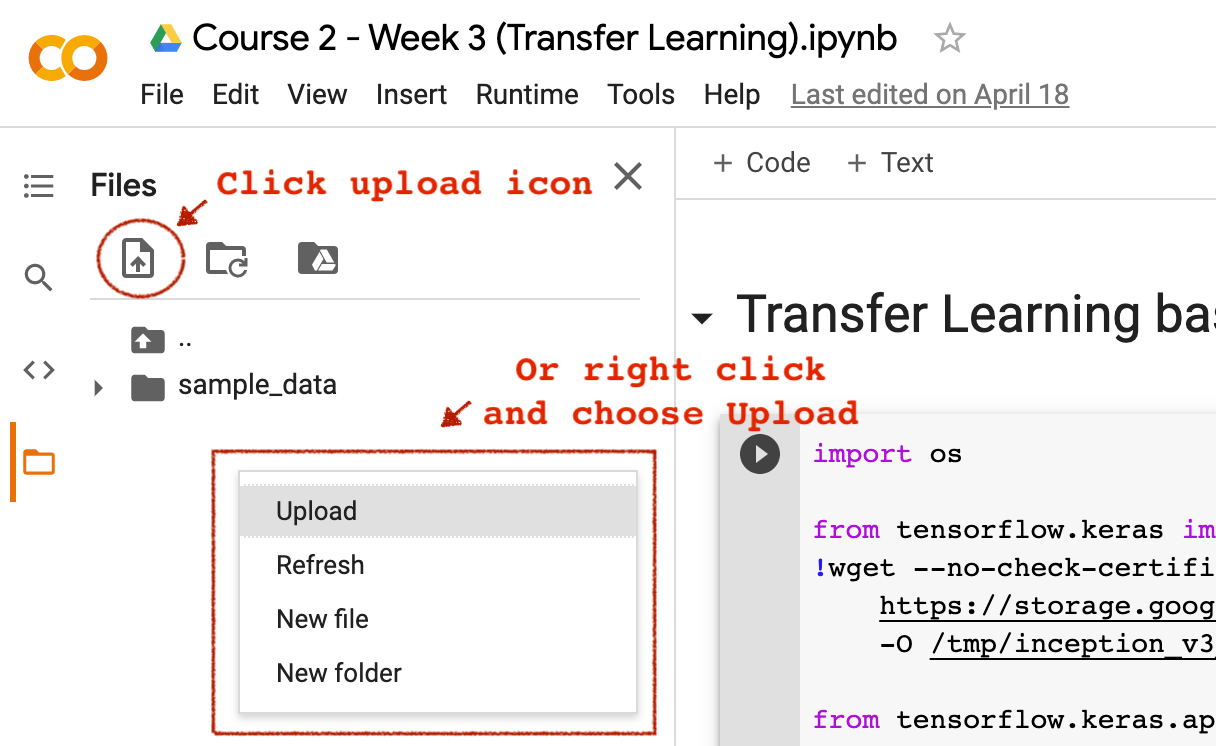)

In [47]:
# Load a CSV File containing Dataset of 500 products, narrative and summary (summary of narrative)
data= pd.read_csv("/content/drive/MyDrive/Complaints_classification.csv")

In [48]:
# Randomly select 30 rows
new_data = data.sample(n=30, random_state=40)

In [49]:
new_data.head()

,product,narrative,summary
167,retail_banking,fraudulent charge totaling made capital one ch...,A fraudulent charge was made on the individual...
169,credit_reporting,block except otherwise provided section consum...,The text outlines various stipulations regardi...
461,credit_card,usaa master plan collect cancellation debt usa...,The input appears to be a complaint about USAA...
253,credit_reporting,block except otherwise provided section consum...,The text pertains to the stipulations and oper...
42,credit_reporting,open account acct opened balance account acct ...,The input is about various accounts being open...


##### **Q2.2: Create a new column in the DataFrame called 'mistral_response' and populate it with responses generated by applying the 'generate_mistral_response' function to each 'narrative' in the DataFrame and prepare the mistral_response_cleaned column using extract_category function** **(1 Marks)**

In [50]:
# example - new_data['mistral_response'] = new_data['narrative'].apply(lambda x:______ )
new_data['mistral_response'] = new_data['narrative'].apply(lambda x: generate_mistral_response(x))

Llama.generate: prefix-match hit

llama_print_timings:        load time =     601.10 ms
llama_print_timings:      sample time =       2.32 ms /     4 runs   (    0.58 ms per token,  1725.63 tokens per second)
llama_print_timings: prompt eval time =     435.43 ms /   269 tokens (    1.62 ms per token,   617.78 tokens per second)
llama_print_timings:        eval time =     110.28 ms /     3 runs   (   36.76 ms per token,    27.20 tokens per second)
llama_print_timings:       total time =     560.05 ms /   272 tokens
Llama.generate: prefix-match hit


 credit\_card



llama_print_timings:        load time =     601.10 ms
llama_print_timings:      sample time =      38.78 ms /    68 runs   (    0.57 ms per token,  1753.48 tokens per second)
llama_print_timings: prompt eval time =     522.97 ms /   504 tokens (    1.04 ms per token,   963.73 tokens per second)
llama_print_timings:        eval time =    2414.42 ms /    67 runs   (   36.04 ms per token,    27.75 tokens per second)
llama_print_timings:       total time =    3163.90 ms /   571 tokens
Llama.generate: prefix-match hit


 consumer reporting

This category includes complaints related to errors or issues with consumer reporting agencies, such as inaccurate information on credit reports or identity theft. The provided text appears to discuss various provisions of the Fair Credit Reporting Act (FCRA) and how a consumer reporting agency should handle blocked information due to identity theft or errors.



llama_print_timings:        load time =     601.10 ms
llama_print_timings:      sample time =       2.37 ms /     4 runs   (    0.59 ms per token,  1688.48 tokens per second)
llama_print_timings: prompt eval time =     387.94 ms /   181 tokens (    2.14 ms per token,   466.56 tokens per second)
llama_print_timings:        eval time =      97.41 ms /     3 runs   (   32.47 ms per token,    30.80 tokens per second)
llama_print_timings:       total time =     498.47 ms /   184 tokens
Llama.generate: prefix-match hit


...

 credit\_reporting



llama_print_timings:        load time =     601.10 ms
llama_print_timings:      sample time =      39.71 ms /    68 runs   (    0.58 ms per token,  1712.24 tokens per second)
llama_print_timings: prompt eval time =     531.13 ms /   504 tokens (    1.05 ms per token,   948.92 tokens per second)
llama_print_timings:        eval time =    2473.79 ms /    67 runs   (   36.92 ms per token,    27.08 tokens per second)
llama_print_timings:       total time =    3237.25 ms /   571 tokens
Llama.generate: prefix-match hit


 consumer reporting

This category includes complaints related to errors or issues with consumer reporting agencies, such as inaccurate information on credit reports or identity theft. The provided text appears to discuss various provisions of the Fair Credit Reporting Act (FCRA) and how a consumer reporting agency should handle blocked information due to identity theft or errors.



llama_print_timings:        load time =     601.10 ms
llama_print_timings:      sample time =       2.95 ms /     5 runs   (    0.59 ms per token,  1696.07 tokens per second)
llama_print_timings: prompt eval time =     213.36 ms /    94 tokens (    2.27 ms per token,   440.57 tokens per second)
llama_print_timings:        eval time =     150.22 ms /     4 runs   (   37.55 ms per token,    26.63 tokens per second)
llama_print_timings:       total time =     382.21 ms /    98 tokens


 credit_reporting


In [52]:
new_data['mistral_response']

,mistral_response
167,credit\_card
169,consumer reporting\n\nThis category includes ...
461,debt\_collection
253,consumer reporting\n\nThis category includes ...
42,retail_banking
369,credit\_reporting
26,mortgages\_and\_loans
377,credit\_reporting
238,credit\_reporting
374,credit\_reporting


In [53]:
def extract_category(text):
    # Define the regex pattern to match "category:" or "Category:" followed by a word
    pattern = r'category:\s*(\w+)'  # The pattern itself remains the same

    # Use re.search with the re.IGNORECASE flag to make it case-insensitive
    match = re.search(pattern, text, re.IGNORECASE)

    # If a match is found, return the captured group, else return None
    if match:
        return match.group(1)
    else:
        pattern1 = r'(credit_card|retail_banking|credit_reporting|mortgages_and_loans|debt_collection)'
        match = re.search(pattern1, text, re.IGNORECASE)
        if match:
            return match.group()
        else:
            return ''

In [54]:
# example - new_data['mistral_response_cleaned'] = new_data['narrative'].apply(lambda x:______ )
new_data['mistral_response_cleaned'] = new_data['mistral_response'].apply(lambda x: extract_category(x) )

In [55]:
new_data.head()

,product,narrative,summary,mistral_response,mistral_response_cleaned
167,retail_banking,fraudulent charge totaling made capital one ch...,A fraudulent charge was made on the individual...,credit\_card,
169,credit_reporting,block except otherwise provided section consum...,The text outlines various stipulations regardi...,consumer reporting\n\nThis category includes ...,
461,credit_card,usaa master plan collect cancellation debt usa...,The input appears to be a complaint about USAA...,debt\_collection,
253,credit_reporting,block except otherwise provided section consum...,The text pertains to the stipulations and oper...,consumer reporting\n\nThis category includes ...,
42,credit_reporting,open account acct opened balance account acct ...,The input is about various accounts being open...,retail_banking,retail_banking


##### **Q2.3: Calculate the F1 score** **(1 Marks)**

In [56]:
# Calculate F1 score for 'product' and 'mistral_response'
f1 =  f1_score(new_data['product'], new_data['mistral_response'],average='micro')

print(f'F1 Score: {f1}')

F1 Score: 0.0


In [57]:
# Calculate F1 score for 'product' and 'mistral_response_cleaned'
f2 =  f1_score(new_data['product'], new_data['mistral_response_cleaned'], average='micro')
print(f'F1 Score: {f2}')

F1 Score: 0.23333333333333334


##### **Q2.4: Explain the difference in F1 scores between mistral_response and mistral_response_cleaned.** **(1 Marks)**

The raw model outputs are free-form text, while the evaluation metric expects exact categorical labels.

### **Question 3: Few-Shot Prompting for Text Classification (7 Marks)**

##### **Q3.1: Prepare examples for a few-shot prompt, formulate the prompt, and generate the Mistral response. (5 Marks)**

**Generate a set of gold examples by randomly selecting 10 instances of user_input and assistant_output from dataset ensuring a balanced representation with 2 examples from each class.**

In [58]:
import json
review_1 = data[data['product'] == 'credit_card']
review_2 = data[data['product'] == 'retail_banking']
review_3 = data[data['product'] == 'credit_reporting']
review_4 = data[data['product'] == 'mortgages_and_loans']
review_5 = data[data['product'] == 'debt_collection']

# Sample 2 examples for each category
examples_1 = review_1.sample(2, random_state=40)
examples_2 = review_2.sample(2, random_state=40)
examples_3 = review_3.sample(2, random_state=40)
examples_4 = review_4.sample(2, random_state=40)
examples_5 = review_5.sample(2, random_state=40)

# Concatenate examples for few shot prompting
examples_df = pd.concat([examples_1,examples_2,examples_3,examples_4,examples_5 ])

# Create the training set by excluding examples
gold_examples_df = data.drop(index=examples_df.index)

# Convert examples to JSON
columns_to_select = ['narrative', 'product']
examples_json = examples_df[columns_to_select].to_json(orient='records')

# Print the first record from the JSON
print(json.loads(examples_json)[0])

# Print the shapes of the datasets
print("Examples Set Shape:", examples_df.shape)
print("Gold Examples Shape:", gold_examples_df.shape)

{'narrative': 'called request new york state covid relief plan day interest fee waived amex provided relief leading late payment amex refused honor relief day gap insists charging late fee', 'product': 'credit_card'}
Examples Set Shape: (10, 3)
Gold Examples Shape: (490, 3)


- Define your **system_message**.
- Define **first_turn_template**, **example_template** and **prediction template**
- **create few shot prompt** using gold examples and system_message
- Randomly select 30 rows from test_df as test_data
- Create **mistral_response** with **mistral_response_cleaned** columns for this

In [63]:
system_message = (

"You are a product classification assistant. "
"Classify the complaint into exactly one of these categories: "
"credit_card, retail_banking, credit_reporting, mortgages_and_loans, debt_collection. "
"Respond with only the category label from the list (no extra words)."
)

In [64]:
first_turn_template = """<s>[INST] <<SYS>> {system_message} <</SYS>>

Complaint: {user_input}
Category: {assistant_output}

"""

examples_template = """Complaint: {user_input}
Category: {assistant_output}

"""

prediction_template = """Complaint: {user_input}
Category: [/INST]"""

In [65]:
def create_few_shot_prompt(system_message, examples_df):

    """
    Return a prompt message in the format expected by Mistral 7b.
    10 examples are selected randomly as golden examples to form the
    few-shot prompt.
    We then loop through each example and parse the narrative as the user message
    and the product as the assistant message.

    Args:
        system_message (str): system message with instructions for classification
        examples(DataFrame): A DataFrame with examples (product + narrative + summary)
        to form the few-shot prompt.

    Output:
        few_shot_prompt (str): A prompt string in the Mistral format
    """

    few_shot_prompt = ''

    columns_to_select = ['narrative', 'product']
    examples = (
        examples_df.loc[:, columns_to_select].to_json(orient='records')
    )

    for idx, example in enumerate(json.loads(examples)):
        user_input_example = example['narrative']
        assistant_output_example = example['product']

        if idx == 0:
            few_shot_prompt += first_turn_template.format(
                system_message=system_message,
                user_input=user_input_example,
                assistant_output=assistant_output_example
            )
        else:
            few_shot_prompt += examples_template.format(
                user_input=user_input_example,
                assistant_output=assistant_output_example
            )

    return few_shot_prompt

In [66]:
few_shot_prompt = create_few_shot_prompt(system_message, examples_df)

In [67]:
print(few_shot_prompt)

<s>[INST] <<SYS>> You are a product classification assistant. Classify the complaint into exactly one of these categories: credit_card, retail_banking, credit_reporting, mortgages_and_loans, debt_collection. Respond with only the category label from the list (no extra words). <</SYS>>

Complaint: called request new york state covid relief plan day interest fee waived amex provided relief leading late payment amex refused honor relief day gap insists charging late fee
Category: credit_card

Complaint: dispute case card ending usaa credit card merchant name transaction date transaction amount disputed amount dispute case card ending usaa credit card merchant name transaction date transaction amount disputed amount dispute making purchase credit card usaa two separate transaction merchant purchased trip cancelled told apply refund apply refund however company give refund back filed dispute credit agency help dispute account follow dispute policy state service provided customer right recei

In [68]:
def generate_prompt(few_shot_prompt,new_review):
    prompt =  few_shot_prompt + prediction_template.format(user_input=new_review)
    return prompt

In [69]:
def generate_mistral_response(support_ticket_text):

    # Combine user_prompt and system_message to create the prompt
    prompt = generate_prompt(few_shot_prompt,support_ticket_text)

    # Define the Llama model along with its parameters for generating a response
    response = lcpp_llm(
        prompt=prompt,
        max_tokens=1200,
        temperature=0,
        top_p=0.95,
        repeat_penalty=1.2,
        top_k=50,
        stop=["/s"],
        echo=False
    )


    # Extract and return the response text
    response_text = response["choices"][0]["text"]
    print(response_text)
    return response_text

In [70]:
# Randomly select 50 rows from gold_examples
new_data = gold_examples_df.sample(n=50, random_state=40)

In [71]:
# example - new_data['mistral_response_cleaned'] = new_data['narrative'].apply(lambda x:______ )
new_data['mistral_response'] = new_data['narrative'].apply(lambda x: generate_mistral_response(x))

Llama.generate: prefix-match hit

llama_print_timings:        load time =     601.10 ms
llama_print_timings:      sample time =       3.65 ms /     6 runs   (    0.61 ms per token,  1644.29 tokens per second)
llama_print_timings: prompt eval time =    2898.87 ms /  2399 tokens (    1.21 ms per token,   827.56 tokens per second)
llama_print_timings:        eval time =     195.84 ms /     5 runs   (   39.17 ms per token,    25.53 tokens per second)
llama_print_timings:       total time =    3129.51 ms /  2404 tokens
Llama.generate: prefix-match hit


 credit_reporting.



llama_print_timings:        load time =     601.10 ms
llama_print_timings:      sample time =       3.22 ms /     6 runs   (    0.54 ms per token,  1862.20 tokens per second)
llama_print_timings: prompt eval time =     595.26 ms /   434 tokens (    1.37 ms per token,   729.09 tokens per second)
llama_print_timings:        eval time =     190.20 ms /     5 runs   (   38.04 ms per token,    26.29 tokens per second)
llama_print_timings:       total time =     805.97 ms /   439 tokens
Llama.generate: prefix-match hit


 credit\_reporting.



llama_print_timings:        load time =     601.10 ms
llama_print_timings:      sample time =      38.69 ms /    69 runs   (    0.56 ms per token,  1783.36 tokens per second)
llama_print_timings: prompt eval time =     251.24 ms /    18 tokens (   13.96 ms per token,    71.64 tokens per second)
llama_print_timings:        eval time =    2537.74 ms /    68 runs   (   37.32 ms per token,    26.80 tokens per second)
llama_print_timings:       total time =    3019.61 ms /    86 tokens
Llama.generate: prefix-match hit


...

 mortgage\_and\_loans (for the last complaint)

Explanation: The complainant is discussing an issue with a mortgage or loan account, specifically mentioning that they are trying to buy a new home but their credit report has missing payment history due to an error made by a specialized loan servicing company. They have contacted the company multiple times and have been promised a letter detailing the resolution, but have not received it yet and need it fixed urgently in order to proceed with their new loan application.



llama_print_timings:        load time =     601.10 ms
llama_print_timings:      sample time =       3.22 ms /     6 runs   (    0.54 ms per token,  1863.93 tokens per second)
llama_print_timings: prompt eval time =     605.23 ms /   422 tokens (    1.43 ms per token,   697.26 tokens per second)
llama_print_timings:        eval time =     194.06 ms /     5 runs   (   38.81 ms per token,    25.77 tokens per second)
llama_print_timings:       total time =     820.31 ms /   427 tokens
Llama.generate: prefix-match hit


 credit\_reporting.



llama_print_timings:        load time =     601.10 ms
llama_print_timings:      sample time =       3.17 ms /     6 runs   (    0.53 ms per token,  1893.34 tokens per second)
llama_print_timings: prompt eval time =     607.52 ms /   434 tokens (    1.40 ms per token,   714.38 tokens per second)
llama_print_timings:        eval time =     195.75 ms /     5 runs   (   39.15 ms per token,    25.54 tokens per second)
llama_print_timings:       total time =     823.70 ms /   439 tokens


 credit\_reporting.


In [72]:
# example - new_data['mistral_response_cleaned'] = new_data['narrative'].apply(lambda x:______ )
new_data['mistral_response_cleaned'] = new_data['mistral_response'].apply(lambda x: extract_category(x))

##### **Q3.2: Calculate the F1 score** **(1 Marks)**

In [73]:
# Calculate F1 score for 'product' and 'mistral_response'
f1 =  f1_score(new_data['product'], new_data['mistral_response_cleaned'], average='micro')

print(f'F1 Score: {f1}')

F1 Score: 0.1


##### **Q3.3: Share your observations on the few-shot and zero-shot prompt techniques. (1 Marks)**

In the zero-shot setting, the model relied only on the system instructions and achieved a higher F1 score (0.233). After introducing few-shot prompting with 10 labeled examples, the F1 score decreased to 0.1. This suggests that the few-shot examples did not help the model generalize better to new complaints and may have introduced bias or confusion. Possible reasons include limited number of examples, lack of representativeness of the selected samples, prompt formatting issues, or increased prompt length affecting model focus. Overall, in this experiment, zero-shot prompting performed better than few-shot prompting.

# **Section 3: Text to Text generation**

### **Question 4: Zero-Shot Prompting for Text Summarization (5 Marks)**

##### **Q4.1: Define the Prompt Template, System Message, generate prompt and model response** **(3 Marks)**


- Define a **system message** as a string and assign it to the variable system_message to generate summary of narrative in data.
- Create a **zero shot prompt template** that incorporates the system message and user input.
- Define **generate_prompt** function that takes both the system_message and user_input as arguments and formats them into a prompt template


Write a Python function called **generate_mistral_response** that takes a single parameter, narrative, which represents the user's complain. Inside the function, you should perform the following tasks:


- **Combine the system_message and narrative to create a prompt string using generate_prompt function.**

*Generate a response from the Mistral model using the lcpp_llm instance with the following parameters:*

- prompt should be the combined prompt string.
- max_tokens should be set to 1200.
- temperature should be set to 0.
- top_p should be set to 0.95.
- repeat_penalty should be set to 1.2.
- top_k should be set to 50.
- stop should be set as a list containing '/s'.
- echo should be set to False.
Extract and return the response text from the generated response.

Don't forget to provide a value for the system_message variable before using it in the function.

In [ ]:
system_message = "_____"

In [ ]:
zero_shot_prompt_template = "_____"

def generate_prompt(system_message,user_input):
    prompt=zero_shot_prompt_template.format(system_message=system_message,user_message=user_input)
    return prompt

def generate_mistral_response(input_text):

    # Combine user_prompt and system_message to create the prompt
    prompt = generate_prompt(system_message,input_text)

    # Define the Llama model along with its parameters for generating a response
    response = "_____"


    # Extract and return the response text
    response_text = response["choices"][0]["text"]
    print(response_text)
    return response_text

##### **Q4.2: Generate mistral_response column containing LLM generated summaries** **(1 Marks)**

In [ ]:
# Randomly select 30 rows
gold_examples = data.sample("_____" , random_state=40)

In [ ]:
# example - new_data['mistral_response_cleaned'] = new_data['narrative'].apply(lambda x:______ )
gold_examples['mistral_response'] = gold_examples['narrative'].apply(lambda x: "_____")

##### **Q4.3: Evaluate bert score** **(1 Marks)**

In [ ]:
def evaluate_score(test_data, scorer, bert_score=False):

    """
    Return the ROUGE score or BERTScore for predictions on gold examples
    For each example we make a prediction using the prompt.
    Gold summaries and the AI generated summaries are aggregated into lists.
    These lists are used by the corresponding scorers to compute metrics.
    Since BERTScore is computed for each candidate-reference pair, we take the
    average F1 score across the gold examples.

    Args:
        prompt (List): list of messages in the Open AI prompt format
        gold_examples (str): JSON string with list of gold examples
        scorer (function): Scorer function used to compute the ROUGE score or the
                           BERTScore
        bert_score (boolean): A flag variable that indicates if BERTScore should
                              be used as the metric.

    Output:
        score (float): BERTScore or ROUGE score computed by comparing model predictions
                       with ground truth
    """

    model_predictions = test_data['mistral_response'].tolist()
    ground_truths = test_data['summary'].tolist()
    if bert_score:
        score = scorer.compute(
            predictions=model_predictions,
            references=ground_truths,
            lang="en",
            rescale_with_baseline=True
        )

        return sum(score['f1'])/len(score['f1'])
    else:
        return scorer.compute(
            predictions=model_predictions,
            references=ground_truths
        )

In [ ]:
bert_scorer = evaluate.load("bertscore")

In [ ]:
score = evaluate_score("_____",
    "_____",
    bert_score=True)

print(f'BERTScore: {score}')